# 03 - PCA / SVD Feature Diagnostics

Phase 3 keeps PCA/SVD artifacts for RAM analysis and ablation. After Phase 9 diagnostic evidence, PCA is no longer assumed to be the default final model input. Raw 777 features from Phase 2 remain the main input for the tabular model zoo.


## Runtime Contract

Run this notebook in Google Colab only. It reads Phase 2 artifacts from Google Drive and writes reduced features under `artifacts/pca/`.

This notebook must not fit PCA/SVD on validation or test data. All trainable preprocessing objects are fit on train only.

In [1]:
# try: kiểm tra môi trường Google Colab (bắt buộc theo chính sách dự án)
try:
    # import google.colab  # type: ignore: import thư viện google
    import google.colab  # type: ignore
# except: xử lý ngoại lệ — except ImportError as exc:
except ImportError as exc:
    # raise RuntimeError(: ném lỗi và dừng cell
    raise RuntimeError(
        # "Run this notebook in Google Colab. Local execution is disabled by project polic...: thực thi lệnh Python
        "Run this notebook in Google Colab. Local execution is disabled by project policy."
    # ) from exc: thực thi lệnh Python
    ) from exc


In [2]:
# from google.colab import drive: import thư viện google
from google.colab import drive

# drive.mount: gắn Drive để đọc feature Phase 2 và lưu PCA output
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# import gc: giải phóng RAM sau các bước PCA nặng
import gc
# import json: đọc/ghi metadata Phase 2 và Phase 3
import json
# import platform: ghi thông tin môi trường Colab vào báo cáo
import platform
# import random: cố định seed
import random
# import time: đo thời gian load/fit/transform
import time
# from datetime import datetime, timezone: import thư viện datetime
from datetime import datetime, timezone
# from pathlib import Path: quản lý đường dẫn
from pathlib import Path

# import joblib: lưu/tải object đã fit
import joblib
# import matplotlib.pyplot: vẽ biểu đồ
import matplotlib.pyplot as plt
# import numpy: tính toán mảng số
import numpy as np
# import pandas: xử lý DataFrame
import pandas as pd
# PCA, IncrementalPCA, TruncatedSVD: các backend giảm chiều
from sklearn.decomposition import PCA, IncrementalPCA, TruncatedSVD
# from sklearn.preprocessing import StandardScaler: thư viện machine learning scikit-learn
from sklearn.preprocessing import StandardScaler

# SEED = 42: seed tái lập kết quả
SEED = 42
# random.seed(SEED): cố định seed random
random.seed(SEED)
# np.random.seed(SEED): cố định seed numpy
np.random.seed(SEED)

# PROJECT_ROOT: thư mục gốc dự án
PROJECT_ROOT = Path('/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews')
# FEATURE_DIR: artifact feature 777 chiều từ Phase 2
FEATURE_DIR = PROJECT_ROOT / 'artifacts' / 'features'
# PCA_DIR: lưu model PCA, feature giảm chiều, scaler
PCA_DIR = PROJECT_ROOT / 'artifacts' / 'pca'
# REPORT_TABLE_DIR: biến cấu hình/hằng số của notebook
REPORT_TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
# REPORT_FIGURE_DIR: biến cấu hình/hằng số của notebook
REPORT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'

# VARIANCE_TARGET = 0.98: giữ 98% phương sai khi chọn số component
VARIANCE_TARGET = 0.98
# VARIANCE_MINIMUM = 0.95: ngưỡng tối thiểu nếu không đạt target
VARIANCE_MINIMUM = 0.95
# TARGET_DIM_MIN/MAX: khoảng chiều mong muốn sau PCA (300–400)
TARGET_DIM_MIN = 300
# TARGET_DIM_MAX: biến cấu hình/hằng số của notebook
TARGET_DIM_MAX = 400
# USE_GLOBAL_SCALER = True: chuẩn hóa toàn bộ feature trước PCA
USE_GLOBAL_SCALER = True
# PCA_BACKEND = 'auto': tự chọn pca / incremental_pca / truncated_svd
PCA_BACKEND = 'auto'  # auto, pca, incremental_pca, truncated_svd
# INCREMENTAL_BATCH_SIZE: batch cho IncrementalPCA (tiết kiệm RAM)
INCREMENTAL_BATCH_SIZE = 2048
# SVD_MAX_COMPONENTS: giới hạn component khi dùng TruncatedSVD
SVD_MAX_COMPONENTS = 500
# FORCE_REBUILD_PCA = False: dùng cache PCA nếu có
FORCE_REBUILD_PCA = False

# FEATURE_PATHS: đường dẫn feature raw 777 chiều từ Phase 2
FEATURE_PATHS = {
    # 'train': FEATURE_DIR / 'features_raw_train.npy',: thực thi lệnh Python
    'train': FEATURE_DIR / 'features_raw_train.npy',
    # 'val': FEATURE_DIR / 'features_raw_val.npy',: thực thi lệnh Python
    'val': FEATURE_DIR / 'features_raw_val.npy',
    # 'test': FEATURE_DIR / 'features_raw_test.npy',: thực thi lệnh Python
    'test': FEATURE_DIR / 'features_raw_test.npy',
# }: đóng khối từ điển
}
# LABEL_PATHS: đường dẫn nhãn .npy
LABEL_PATHS = {
    # 'train': FEATURE_DIR / 'labels_train.npy',: thực thi lệnh Python
    'train': FEATURE_DIR / 'labels_train.npy',
    # 'val': FEATURE_DIR / 'labels_val.npy',: thực thi lệnh Python
    'val': FEATURE_DIR / 'labels_val.npy',
    # 'test': FEATURE_DIR / 'labels_test.npy',: thực thi lệnh Python
    'test': FEATURE_DIR / 'labels_test.npy',
# }: đóng khối từ điển
}
# PHASE2_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE2_METADATA_PATH = FEATURE_DIR / 'feature_metadata.json'

# tạo thư mục output PCA và báo cáo
for path in [PCA_DIR, REPORT_TABLE_DIR, REPORT_FIGURE_DIR]:
    # path.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
    path.mkdir(parents=True, exist_ok=True)

# pd.set_option('display.max_columns', 100): cấu hình hiển thị pandas
pd.set_option('display.max_columns', 100)
# print('Project root:', PROJECT_ROOT): in thông tin ra console
print('Project root:', PROJECT_ROOT)


Project root: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews


## PCA-01 Preflight - Validate Phase 2 Inputs

This section validates Phase 2 artifacts without fitting anything. It fails fast if feature rows, label rows, dimensions, or metadata are inconsistent.

In [4]:
# required_paths: file feature/label/metadata bắt buộc từ Phase 2
required_paths = list(FEATURE_PATHS.values()) + list(LABEL_PATHS.values()) + [PHASE2_METADATA_PATH]
# missing_paths = ...: kiểm tra file/thư mục tồn tại
missing_paths = [str(path) for path in required_paths if not path.exists()]
# if: điều kiện — if missing_paths:
if missing_paths:
    # raise FileNotFoundError(f'Missing required Phase 2 artifacts: {missing_paths}'): ném lỗi và dừng cell
    raise FileNotFoundError(f'Missing required Phase 2 artifacts: {missing_paths}')

# phase2_metadata: đọc metadata fusion 777 chiều
with open(PHASE2_METADATA_PATH, 'r', encoding='utf-8') as f:
    # phase2_metadata = ...: parse nội dung JSON
    phase2_metadata = json.load(f)

# expected_rows/expected_input_dim: số dòng và chiều kỳ vọng từ Phase 2
expected_rows = phase2_metadata.get('row_counts', {})
# expected_input_dim = ...: ép kiểu số nguyên
expected_input_dim = int(phase2_metadata.get('fusion', {}).get('fused_dim', 0) or 0)
# if: điều kiện — if expected_input_dim <= 0:
if expected_input_dim <= 0:
    # expected_input_dim = ...: gán giá trị cho biến expected input dim
    expected_input_dim = 777

# feature_mmaps/label_mmaps: memory-map .npy để validate không tốn RAM
feature_mmaps = {split: np.load(path, mmap_mode='r') for split, path in FEATURE_PATHS.items()}
# label_mmaps = ...: nạp mảng từ file .npy
label_mmaps = {split: np.load(path, mmap_mode='r') for split, path in LABEL_PATHS.items()}

# validation_rows: kiểm tra shape/dtype/row count trước khi PCA
validation_rows = []
# for: vòng lặp — for split in ['train', 'val', 'test']:
for split in ['train', 'val', 'test']:
    # features = ...: gán giá trị cho biến features
    features = feature_mmaps[split]
    # labels = ...: gán giá trị cho biến labels
    labels = label_mmaps[split]
    # row_count = ...: ép kiểu số nguyên
    row_count = int(features.shape[0])
    # feature_dim = ...: ép kiểu số nguyên
    feature_dim = int(features.shape[1]) if features.ndim == 2 else -1
    # label_rows = ...: ép kiểu số nguyên
    label_rows = int(labels.shape[0])
    # expected_split_rows = ...: ép kiểu số nguyên
    expected_split_rows = int(expected_rows.get(split, row_count))

    # status = ...: gán giá trị cho biến status
    status = 'pass'
    # issues = ...: gán giá trị cho biến issues
    issues = []
    # if: điều kiện — if features.ndim != 2:
    if features.ndim != 2:
        # status = ...: gán giá trị cho biến status
        status = 'fail'
        # issues.append('feature array is not 2D'): thực thi lệnh Python
        issues.append('feature array is not 2D')
    # if: điều kiện — if row_count != expected_split_rows:
    if row_count != expected_split_rows:
        # status = ...: gán giá trị cho biến status
        status = 'fail'
        # issues.append(f'row count mismatch: {row_count} vs {expected_split_rows}'): thực thi lệnh Python
        issues.append(f'row count mismatch: {row_count} vs {expected_split_rows}')
    # if: điều kiện — if label_rows != row_count:
    if label_rows != row_count:
        # status = ...: gán giá trị cho biến status
        status = 'fail'
        # issues.append(f'label row mismatch: {label_rows} vs {row_count}'): thực thi lệnh Python
        issues.append(f'label row mismatch: {label_rows} vs {row_count}')
    # if: điều kiện — if feature_dim != expected_input_dim:
    if feature_dim != expected_input_dim:
        # status = ...: gán giá trị cho biến status
        status = 'fail'
        # issues.append(f'feature dim mismatch: {feature_dim} vs {expected_input_dim}'): thực thi lệnh Python
        issues.append(f'feature dim mismatch: {feature_dim} vs {expected_input_dim}')

    # validation_rows.append({: thực thi lệnh Python
    validation_rows.append({
        # 'split': split,: thực thi lệnh Python
        'split': split,
        # 'feature_rows': row_count,: thực thi lệnh Python
        'feature_rows': row_count,
        # 'feature_dim': feature_dim,: thực thi lệnh Python
        'feature_dim': feature_dim,
        # 'feature_dtype': str(features.dtype),: ép kiểu chuỗi
        'feature_dtype': str(features.dtype),
        # 'label_rows': label_rows,: thực thi lệnh Python
        'label_rows': label_rows,
        # 'label_dtype': str(labels.dtype),: ép kiểu chuỗi
        'label_dtype': str(labels.dtype),
        # 'expected_rows': expected_split_rows,: thực thi lệnh Python
        'expected_rows': expected_split_rows,
        # 'expected_dim': expected_input_dim,: thực thi lệnh Python
        'expected_dim': expected_input_dim,
        # 'status': status,: thực thi lệnh Python
        'status': status,
        # 'issues': '; '.join(issues),: thực thi lệnh Python
        'issues': '; '.join(issues),
    # }): đóng từ điển hoặc DataFrame constructor
    })

# phase3_input_validation = ...: gán giá trị cho biến phase3 input validation
phase3_input_validation = pd.DataFrame(validation_rows)
# input_validation_path = ...: gán giá trị cho biến input validation path
input_validation_path = REPORT_TABLE_DIR / 'phase3_input_validation.csv'
# phase3_input_validation.to_csv(input_validation_path, index=False): ghi DataFrame ra file CSV
phase3_input_validation.to_csv(input_validation_path, index=False)
# display(phase3_input_validation): hiển thị bảng/kết quả trên notebook
display(phase3_input_validation)

# if: điều kiện — if (phase3_input_validation['status'] != 'pass').any():
if (phase3_input_validation['status'] != 'pass').any():
    # raise ValueError('Phase 3 input validation failed. Check phase3_input_validation...: ném lỗi và dừng cell
    raise ValueError('Phase 3 input validation failed. Check phase3_input_validation.csv.')

# print('Saved input validation:', input_validation_path): in thông tin ra console
print('Saved input validation:', input_validation_path)


,split,feature_rows,feature_dim,feature_dtype,label_rows,label_dtype,expected_rows,expected_dim,status,issues
0,train,29923,777,float32,29923,int64,29923,777,pass,
1,val,6413,777,float32,6413,int64,6413,777,pass,
2,test,6413,777,float32,6413,int64,6413,777,pass,


Saved input validation: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase3_input_validation.csv


In [5]:
# array_memory_mb: ước lượng dung lượng RAM (MB) của array hoặc shape
def array_memory_mb(array_or_shape, dtype=None):
    # if: điều kiện — if hasattr(array_or_shape, 'nbytes'):
    if hasattr(array_or_shape, 'nbytes'):
        # return: trả kết quả từ hàm
        return round(float(array_or_shape.nbytes) / (1024 ** 2), 4)
    # if: điều kiện — if dtype is None:
    if dtype is None:
        # raise ValueError('dtype is required when passing a shape'): ném lỗi và dừng cell
        raise ValueError('dtype is required when passing a shape')
    # size = ...: ép kiểu số nguyên
    size = int(np.prod(array_or_shape)) * np.dtype(dtype).itemsize
    # return: trả kết quả từ hàm
    return round(float(size) / (1024 ** 2), 4)


# process_memory_mb: RAM tiến trình hiện tại (MB)
def process_memory_mb():
    # try/except: khối xử lý ngoại lệ
    try:
        # import psutil: import thư viện psutil
        import psutil

        # return: trả kết quả từ hàm
        return round(psutil.Process().memory_info().rss / (1024 ** 2), 4)
    # except: xử lý ngoại lệ — except Exception:
    except Exception:
        # return: trả kết quả từ hàm
        return np.nan


# memory_rows = ...: gán giá trị cho biến memory rows
memory_rows = []
# for: vòng lặp — for split, mmap_array in feature_mmaps.items():
for split, mmap_array in feature_mmaps.items():
    # memory_rows.append({: thực thi lệnh Python
    memory_rows.append({
        # 'stage': 'raw',: thực thi lệnh Python
        'stage': 'raw',
        # 'split': split,: thực thi lệnh Python
        'split': split,
        # 'artifact': FEATURE_PATHS[split].name,: thực thi lệnh Python
        'artifact': FEATURE_PATHS[split].name,
        # 'shape': str(tuple(mmap_array.shape)),: ép kiểu chuỗi
        'shape': str(tuple(mmap_array.shape)),
        # 'dtype': str(mmap_array.dtype),: ép kiểu chuỗi
        'dtype': str(mmap_array.dtype),
        # 'memory_mb': array_memory_mb(mmap_array),: thực thi lệnh Python
        'memory_mb': array_memory_mb(mmap_array),
        # 'process_memory_mb': process_memory_mb(),: thực thi lệnh Python
        'process_memory_mb': process_memory_mb(),
    # }): đóng từ điển hoặc DataFrame constructor
    })

# raw_memory_report = ...: gán giá trị cho biến raw memory report
raw_memory_report = pd.DataFrame(memory_rows)
# display(raw_memory_report): hiển thị bảng/kết quả trên notebook
display(raw_memory_report)


,stage,split,artifact,shape,dtype,memory_mb,process_memory_mb
0,raw,train,features_raw_train.npy,"(29923, 777)",float32,88.6924,246.582
1,raw,val,features_raw_val.npy,"(6413, 777)",float32,19.0083,246.582
2,raw,test,features_raw_test.npy,"(6413, 777)",float32,19.0083,246.582


## PCA-01 and PCA-02 - Train-Only Scaling and Reducer Selection

The optional global scaler and dimensionality reducer are fit on train only. Validation and test use `transform` only.

In [6]:
# load_float32: nạp file .npy và ép kiểu float32
def load_float32(path):
    # array = ...: nạp mảng từ file .npy
    array = np.load(path)
    # if: điều kiện — if array.dtype != np.float32:
    if array.dtype != np.float32:
        # array = ...: ép kiểu dữ liệu cột
        array = array.astype(np.float32)
    # return: trả kết quả từ hàm
    return array


# start_load: đo thời gian nạp feature matrix 777 chiều từ Phase 2
start_load = time.time()
# X_raw = ...: ép kiểu số thực
X_raw = {split: load_float32(path) for split, path in FEATURE_PATHS.items()}
# y: dictionary nhãn nhị phân
y = {split: np.load(path).astype(np.int64) for split, path in LABEL_PATHS.items()}
# load_elapsed = ...: gán giá trị cho biến load elapsed
load_elapsed = time.time() - start_load

# for: vòng lặp — for split in ['train', 'val', 'test']:
for split in ['train', 'val', 'test']:
    # if: điều kiện — if X_raw[split].shape[0] != y[split].shape[0]:
    if X_raw[split].shape[0] != y[split].shape[0]:
        # raise ValueError(f'{split} feature/label row mismatch'): ném lỗi và dừng cell
        raise ValueError(f'{split} feature/label row mismatch')
    # if: điều kiện — if not np.isfinite(X_raw[split]).all():
    if not np.isfinite(X_raw[split]).all():
        # raise ValueError(f'{split} raw features contain non-finite values'): ném lỗi và dừng cell
        raise ValueError(f'{split} raw features contain non-finite values')

# print('Loaded raw arrays in seconds:', round(load_elapsed, 3)): in thông tin ra console
print('Loaded raw arrays in seconds:', round(load_elapsed, 3))
# print({split: X_raw[split].shape for split in X_raw}): in thông tin ra console
print({split: X_raw[split].shape for split in X_raw})


Loaded raw arrays in seconds: 0.963
{'train': (29923, 777), 'val': (6413, 777), 'test': (6413, 777)}


In [7]:
# scaler: StandardScaler toàn cục trước PCA (fit chỉ trên train)
scaler = None
# scaler_path: đường dẫn lưu scaler đã fit
scaler_path = PCA_DIR / 'pca_scaler.joblib'

# if USE_GLOBAL_SCALER: chuẩn hóa feature trước khi giảm chiều
if USE_GLOBAL_SCALER:
    # scaler = ...: gán giá trị cho biến scaler
    scaler = StandardScaler(copy=True)
    # X_model = ...: xóa biến để giải phóng RAM/VRAM
    X_model = {
        # 'train': scaler.fit_transform(X_raw['train']).astype(np.float32),: fit scaler trên train và transform
        'train': scaler.fit_transform(X_raw['train']).astype(np.float32),
        # 'val': scaler.transform(X_raw['val']).astype(np.float32),: transform dữ liệu bằng object đã fit
        'val': scaler.transform(X_raw['val']).astype(np.float32),
        # 'test': scaler.transform(X_raw['test']).astype(np.float32),: transform dữ liệu bằng object đã fit
        'test': scaler.transform(X_raw['test']).astype(np.float32),
    # }: đóng khối từ điển
    }
    # joblib.dump(scaler, scaler_path): lưu object (scaler/model) ra disk
    joblib.dump(scaler, scaler_path)
    # scaler_status = ...: fit model/reducer trên dữ liệu train
    scaler_status = 'fit_train_only'
# else: nhánh còn lại của điều kiện
else:
    # X_model = ...: ép kiểu dữ liệu cột
    X_model = {split: X_raw[split].astype(np.float32, copy=False) for split in ['train', 'val', 'test']}
    # scaler_path = ...: gán giá trị cho biến scaler path
    scaler_path = None
    # scaler_status = ...: gán giá trị cho biến scaler status
    scaler_status = 'not_used'

# for: vòng lặp — for split in ['train', 'val', 'test']:
for split in ['train', 'val', 'test']:
    # if: điều kiện — if not np.isfinite(X_model[split]).all():
    if not np.isfinite(X_model[split]).all():
        # raise ValueError(f'{split} model input contains non-finite values after scaling'...: ném lỗi và dừng cell
        raise ValueError(f'{split} model input contains non-finite values after scaling')

# print('Scaler status:', scaler_status): in thông tin ra console
print('Scaler status:', scaler_status)
# print('Scaler path:', scaler_path): in thông tin ra console
print('Scaler path:', scaler_path)
# gc.collect(): giải phóng bộ nhớ
gc.collect()


Scaler status: fit_train_only
Scaler path: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/pca/pca_scaler.joblib


22

In [8]:
# is_memory_exception: nhận diện lỗi OOM để fallback backend PCA khác
def is_memory_exception(exc):
    # message = ...: ép kiểu chuỗi
    message = str(exc).lower()
    # return: trả kết quả từ hàm
    return isinstance(exc, MemoryError) or 'unable to allocate' in message or 'memory' in message or 'allocation' in message


# fit_selection_reducer: fit PCA/IncrementalPCA/TruncatedSVD trên train
def fit_selection_reducer(backend, train_array):
    # feature_dim = ...: gán giá trị cho biến feature dim
    feature_dim = train_array.shape[1]
    # if: điều kiện — if backend == 'pca':
    if backend == 'pca':
        # model = ...: xóa biến để giải phóng RAM/VRAM
        model = PCA(n_components=None, svd_solver='full', random_state=SEED)
        # model.fit(train_array): fit model/reducer trên dữ liệu train
        model.fit(train_array)
        # return: trả kết quả từ hàm
        return model
    # if: điều kiện — if backend == 'incremental_pca':
    if backend == 'incremental_pca':
        # n_components = ...: gán giá trị cho biến n components
        n_components = feature_dim
        # batch_size = ...: lấy giá trị lớn nhất
        batch_size = max(INCREMENTAL_BATCH_SIZE, n_components)
        # model = ...: xóa biến để giải phóng RAM/VRAM
        model = IncrementalPCA(n_components=n_components, batch_size=batch_size)
        # model.fit(train_array): fit model/reducer trên dữ liệu train
        model.fit(train_array)
        # return: trả kết quả từ hàm
        return model
    # if: điều kiện — if backend == 'truncated_svd':
    if backend == 'truncated_svd':
        # n_components = ...: lấy giá trị nhỏ nhất
        n_components = min(SVD_MAX_COMPONENTS, feature_dim - 1)
        # if: điều kiện — if n_components < 2:
        if n_components < 2:
            # raise ValueError('TruncatedSVD requires at least 2 components'): ném lỗi và dừng cell
            raise ValueError('TruncatedSVD requires at least 2 components')
        # model = ...: xóa biến để giải phóng RAM/VRAM
        model = TruncatedSVD(n_components=n_components, n_iter=7, random_state=SEED)
        # model.fit(train_array): fit model/reducer trên dữ liệu train
        model.fit(train_array)
        # return: trả kết quả từ hàm
        return model
    # raise ValueError(f'Unknown backend: {backend}'): ném lỗi và dừng cell
    raise ValueError(f'Unknown backend: {backend}')


# fit_final_reducer: hàm xử lý fit final reducer
def fit_final_reducer(backend, selected_components, train_array):
    # if: điều kiện — if backend == 'pca':
    if backend == 'pca':
        # model = ...: xóa biến để giải phóng RAM/VRAM
        model = PCA(n_components=selected_components, svd_solver='full', random_state=SEED)
    # elif: nhánh điều kiện phụ — elif backend == 'incremental_pca':
    elif backend == 'incremental_pca':
        # batch_size = ...: lấy giá trị lớn nhất
        batch_size = max(INCREMENTAL_BATCH_SIZE, selected_components)
        # model = ...: xóa biến để giải phóng RAM/VRAM
        model = IncrementalPCA(n_components=selected_components, batch_size=batch_size)
    # elif: nhánh điều kiện phụ — elif backend == 'truncated_svd':
    elif backend == 'truncated_svd':
        # model = ...: xóa biến để giải phóng RAM/VRAM
        model = TruncatedSVD(n_components=selected_components, n_iter=7, random_state=SEED)
    # else: nhánh còn lại của điều kiện
    else:
        # raise ValueError(f'Unknown backend: {backend}'): ném lỗi và dừng cell
        raise ValueError(f'Unknown backend: {backend}')
    # model.fit(train_array): fit model/reducer trên dữ liệu train
    model.fit(train_array)
    # return: trả kết quả từ hàm
    return model


# choose_component_count: hàm xử lý choose component count
def choose_component_count(cumulative_variance):
    # cumulative_variance = ...: ép kiểu số thực
    cumulative_variance = np.asarray(cumulative_variance, dtype=float)
    # max_available = ...: đếm số phần tử
    max_available = len(cumulative_variance)

    # variance_at: hàm xử lý variance at
    def variance_at(n_components):
        # if: điều kiện — if n_components <= 0:
        if n_components <= 0:
            # return: trả kết quả từ hàm
            return 0.0
        # idx = ...: lấy giá trị nhỏ nhất
        idx = min(n_components, max_available) - 1
        # return: trả kết quả từ hàm
        return float(cumulative_variance[idx])

    # target_hits = ...: gán giá trị cho biến target hits
    target_hits = np.flatnonzero(cumulative_variance >= VARIANCE_TARGET)
    # minimum_hits = ...: lấy giá trị nhỏ nhất
    minimum_hits = np.flatnonzero(cumulative_variance >= VARIANCE_MINIMUM)
    # n_at_target = ...: đếm số phần tử
    n_at_target = int(target_hits[0] + 1) if len(target_hits) else None
    # n_at_minimum = ...: đếm số phần tử
    n_at_minimum = int(minimum_hits[0] + 1) if len(minimum_hits) else None

    # target_min = ...: lấy giá trị nhỏ nhất
    target_min = min(TARGET_DIM_MIN, max_available)
    # target_max = ...: lấy giá trị nhỏ nhất
    target_max = min(TARGET_DIM_MAX, max_available)
    # variance_at_min = ...: lấy giá trị nhỏ nhất
    variance_at_min = variance_at(target_min)
    # variance_at_max = ...: lấy giá trị lớn nhất
    variance_at_max = variance_at(target_max)

    # if: điều kiện — if n_at_target is None:
    if n_at_target is None:
        # if: điều kiện — if variance_at_max >= VARIANCE_MINIMUM:
        if variance_at_max >= VARIANCE_MINIMUM:
            # selected = ...: lấy giá trị lớn nhất
            selected = target_max
            # reason = ...: lấy giá trị nhỏ nhất
            reason = 'target_not_reached_but_preferred_max_meets_minimum_variance'
        # else: nhánh còn lại của điều kiện
        else:
            # selected = ...: lấy giá trị lớn nhất
            selected = max_available
            # reason = ...: lấy giá trị lớn nhất
            reason = 'target_not_reached_use_max_available_components'
    # elif: nhánh điều kiện phụ — elif n_at_target < target_min:
    elif n_at_target < target_min:
        # selected = ...: lấy giá trị nhỏ nhất
        selected = target_min
        # reason = ...: tạo dãy số cho vòng lặp
        reason = 'target_met_below_preferred_range_use_target_min_dimension'
    # elif: nhánh điều kiện phụ — elif n_at_target <= target_max:
    elif n_at_target <= target_max:
        # selected = ...: gán giá trị cho biến selected
        selected = n_at_target
        # reason = ...: tạo dãy số cho vòng lặp
        reason = 'target_met_inside_preferred_dimension_range'
    # else: nhánh còn lại của điều kiện
    else:
        # if: điều kiện — if variance_at_max >= VARIANCE_MINIMUM:
        if variance_at_max >= VARIANCE_MINIMUM:
            # selected = ...: lấy giá trị lớn nhất
            selected = target_max
            # reason = ...: tạo dãy số cho vòng lặp
            reason = 'target_requires_above_preferred_range_but_target_max_meets_minimum'
        # else: nhánh còn lại của điều kiện
        else:
            # selected = ...: gán giá trị cho biến selected
            selected = n_at_target
            # reason = ...: tạo dãy số cho vòng lặp
            reason = 'target_requires_above_preferred_range_to_preserve_variance'

    # selected = ...: ép kiểu số nguyên
    selected = int(max(1, min(selected, max_available)))
    # return: trả kết quả từ hàm
    return {
        # 'selected_components': selected,: thực thi lệnh Python
        'selected_components': selected,
        # 'explained_variance_retained': variance_at(selected),: thực thi lệnh Python
        'explained_variance_retained': variance_at(selected),
        # 'n_components_at_target': n_at_target,: thực thi lệnh Python
        'n_components_at_target': n_at_target,
        # 'n_components_at_minimum': n_at_minimum,: lấy giá trị nhỏ nhất
        'n_components_at_minimum': n_at_minimum,
        # 'variance_at_target_dim_min': variance_at_min,: lấy giá trị nhỏ nhất
        'variance_at_target_dim_min': variance_at_min,
        # 'variance_at_target_dim_max': variance_at_max,: lấy giá trị lớn nhất
        'variance_at_target_dim_max': variance_at_max,
        # 'selection_reason': reason,: thực thi lệnh Python
        'selection_reason': reason,
        # 'max_available_components': max_available,: lấy giá trị lớn nhất
        'max_available_components': max_available,
    # }: đóng khối từ điển
    }


In [9]:
# backend_order: thứ tự thử backend giảm chiều (auto → thử lần lượt)
backend_order = ['pca', 'incremental_pca', 'truncated_svd'] if PCA_BACKEND == 'auto' else [PCA_BACKEND]
# backend_errors = ...: gán giá trị cho biến backend errors
backend_errors = []
# selection_model = ...: xóa biến để giải phóng RAM/VRAM
selection_model = None
# selected_backend = ...: gán giá trị cho biến selected backend
selected_backend = None

# fit_start: đo thời gian fit reducer
fit_start = time.time()
# for backend: thử từng backend cho đến khi thành công hoặc hết
for backend in backend_order:
    # try/except: khối xử lý ngoại lệ
    try:
        # print('Trying reducer backend:', backend): in thông tin ra console
        print('Trying reducer backend:', backend)
        # selection_model = ...: xóa biến để giải phóng RAM/VRAM
        selection_model = fit_selection_reducer(backend, X_model['train'])
        # selected_backend = ...: gán giá trị cho biến selected backend
        selected_backend = backend
        break
    # except: xử lý ngoại lệ — except Exception as exc:
    except Exception as exc:
        # backend_errors.append({'backend': backend, 'error': repr(exc)}): thực thi lệnh Python
        backend_errors.append({'backend': backend, 'error': repr(exc)})
        # print(f'Backend {backend} failed:', repr(exc)): in thông tin ra console
        print(f'Backend {backend} failed:', repr(exc))
        # if: điều kiện — if PCA_BACKEND != 'auto' or not is_memory_exception(exc):
        if PCA_BACKEND != 'auto' or not is_memory_exception(exc):
            # raise: ném lỗi và dừng cell
            raise
        # gc.collect(): giải phóng bộ nhớ
        gc.collect()

# if: điều kiện — if selection_model is None or selected_backend is None:
if selection_model is None or selected_backend is None:
    # raise RuntimeError(f'No reducer backend could be fit. Errors: {backend_errors}'): ném lỗi và dừng cell
    raise RuntimeError(f'No reducer backend could be fit. Errors: {backend_errors}')

# explained_variance_ratio = ...: ép kiểu số thực
explained_variance_ratio = np.asarray(selection_model.explained_variance_ratio_, dtype=float)
# cumulative_explained_variance = ...: tính tổng
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
# selection = ...: gán giá trị cho biến selection
selection = choose_component_count(cumulative_explained_variance)

# final_reducer = ...: fit model/reducer trên dữ liệu train
final_reducer = fit_final_reducer(
    # selected_backend,: thực thi lệnh Python
    selected_backend,
    # selection['selected_components'],: thực thi lệnh Python
    selection['selected_components'],
    # X_model['train'],: thực thi lệnh Python
    X_model['train'],
# ): đóng ngoặc gọi hàm
)
# fit_elapsed = ...: fit model/reducer trên dữ liệu train
fit_elapsed = time.time() - fit_start

# reducer_path = ...: gán giá trị cho biến reducer path
reducer_path = PCA_DIR / 'pca_or_svd.joblib'
# joblib.dump(final_reducer, reducer_path): lưu object (scaler/model) ra disk
joblib.dump(final_reducer, reducer_path)

# component_variance = ...: gán giá trị cho biến component variance
component_variance = pd.DataFrame({
    # 'component': np.arange(1, len(explained_variance_ratio) + 1),: tạo dãy số cho vòng lặp
    'component': np.arange(1, len(explained_variance_ratio) + 1),
    # 'explained_variance_ratio': explained_variance_ratio,: thực thi lệnh Python
    'explained_variance_ratio': explained_variance_ratio,
    # 'cumulative_explained_variance': cumulative_explained_variance,: thực thi lệnh Python
    'cumulative_explained_variance': cumulative_explained_variance,
# }): đóng từ điển hoặc DataFrame constructor
})
# component_variance_path = ...: gán giá trị cho biến component variance path
component_variance_path = REPORT_TABLE_DIR / 'phase3_component_variance.csv'
# component_variance.to_csv(component_variance_path, index=False): ghi DataFrame ra file CSV
component_variance.to_csv(component_variance_path, index=False)

# selection_report = ...: gán giá trị cho biến selection report
selection_report = pd.DataFrame([{
    # 'backend': selected_backend,: thực thi lệnh Python
    'backend': selected_backend,
    # 'input_dim': int(X_model['train'].shape[1]),: ép kiểu số nguyên
    'input_dim': int(X_model['train'].shape[1]),
    # 'selected_components': int(selection['selected_components']),: ép kiểu số nguyên
    'selected_components': int(selection['selected_components']),
    # 'explained_variance_retained': float(selection['explained_variance_retained']),: ép kiểu số thực
    'explained_variance_retained': float(selection['explained_variance_retained']),
    # 'variance_target': VARIANCE_TARGET,: thực thi lệnh Python
    'variance_target': VARIANCE_TARGET,
    # 'variance_minimum': VARIANCE_MINIMUM,: lấy giá trị nhỏ nhất
    'variance_minimum': VARIANCE_MINIMUM,
    # 'target_dim_min': TARGET_DIM_MIN,: lấy giá trị nhỏ nhất
    'target_dim_min': TARGET_DIM_MIN,
    # 'target_dim_max': TARGET_DIM_MAX,: lấy giá trị lớn nhất
    'target_dim_max': TARGET_DIM_MAX,
    # 'n_components_at_target': selection['n_components_at_target'],: thực thi lệnh Python
    'n_components_at_target': selection['n_components_at_target'],
    # 'n_components_at_minimum': selection['n_components_at_minimum'],: lấy giá trị nhỏ nhất
    'n_components_at_minimum': selection['n_components_at_minimum'],
    # 'variance_at_target_dim_min': selection['variance_at_target_dim_min'],: lấy giá trị nhỏ nhất
    'variance_at_target_dim_min': selection['variance_at_target_dim_min'],
    # 'variance_at_target_dim_max': selection['variance_at_target_dim_max'],: lấy giá trị lớn nhất
    'variance_at_target_dim_max': selection['variance_at_target_dim_max'],
    # 'max_available_components': selection['max_available_components'],: lấy giá trị lớn nhất
    'max_available_components': selection['max_available_components'],
    # 'selection_reason': selection['selection_reason'],: thực thi lệnh Python
    'selection_reason': selection['selection_reason'],
    # 'fit_elapsed_seconds': round(fit_elapsed, 3),: làm tròn số
    'fit_elapsed_seconds': round(fit_elapsed, 3),
    # 'scaler_status': scaler_status,: thực thi lệnh Python
    'scaler_status': scaler_status,
    # 'reducer_path': str(reducer_path),: ép kiểu chuỗi
    'reducer_path': str(reducer_path),
    # 'scaler_path': str(scaler_path) if scaler_path is not None else '',: ép kiểu chuỗi
    'scaler_path': str(scaler_path) if scaler_path is not None else '',
    # 'backend_errors': json.dumps(backend_errors),: ghi dictionary ra JSON
    'backend_errors': json.dumps(backend_errors),
# }]): đóng khối cú pháp Python
}])
# selection_report_path = ...: gán giá trị cho biến selection report path
selection_report_path = REPORT_TABLE_DIR / 'phase3_pca_selection_report.csv'
# selection_report.to_csv(selection_report_path, index=False): ghi DataFrame ra file CSV
selection_report.to_csv(selection_report_path, index=False)

# display(selection_report): hiển thị bảng/kết quả trên notebook
display(selection_report)
# print('Saved reducer:', reducer_path): in thông tin ra console
print('Saved reducer:', reducer_path)
# print('Saved selection report:', selection_report_path): in thông tin ra console
print('Saved selection report:', selection_report_path)
# print('Saved component variance:', component_variance_path): in thông tin ra console
print('Saved component variance:', component_variance_path)


Trying reducer backend: pca


,backend,input_dim,selected_components,explained_variance_retained,variance_target,variance_minimum,target_dim_min,target_dim_max,n_components_at_target,n_components_at_minimum,variance_at_target_dim_min,variance_at_target_dim_max,max_available_components,selection_reason,fit_elapsed_seconds,scaler_status,reducer_path,scaler_path,backend_errors
0,pca,777,400,0.95103,0.98,0.95,300,400,549,397,0.917166,0.95103,777,target_requires_above_preferred_range_but_targ...,5.235,fit_train_only,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,[]


Saved reducer: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/pca/pca_or_svd.joblib
Saved selection report: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase3_pca_selection_report.csv
Saved component variance: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase3_component_variance.csv


## PCA-03 and PCA-04 - Transform, Export, and Report

The final reducer transforms all splits with the same selected component count. Reduced arrays are saved as `float32`.

In [10]:
# feature_final_paths: đường dẫn lưu feature sau giảm chiều PCA
feature_final_paths = {
    # 'train': PCA_DIR / 'features_final_train.npy',: thực thi lệnh Python
    'train': PCA_DIR / 'features_final_train.npy',
    # 'val': PCA_DIR / 'features_final_val.npy',: thực thi lệnh Python
    'val': PCA_DIR / 'features_final_val.npy',
    # 'test': PCA_DIR / 'features_final_test.npy',: thực thi lệnh Python
    'test': PCA_DIR / 'features_final_test.npy',
# }: đóng khối từ điển
}
# label_final_paths: copy nhãn sang thư mục PCA (đồng bộ artifact)
label_final_paths = {
    # 'train': PCA_DIR / 'labels_train.npy',: thực thi lệnh Python
    'train': PCA_DIR / 'labels_train.npy',
    # 'val': PCA_DIR / 'labels_val.npy',: thực thi lệnh Python
    'val': PCA_DIR / 'labels_val.npy',
    # 'test': PCA_DIR / 'labels_test.npy',: thực thi lệnh Python
    'test': PCA_DIR / 'labels_test.npy',
# }: đóng khối từ điển
}

# selected_components: số chiều cuối cùng được chọn theo variance target
selected_components = int(selection['selected_components'])
# features_final = ...: gán giá trị cho biến features final
features_final = {}
# transform_start: đo thời gian transform train/val/test
transform_start = time.time()
# for split: giảm chiều và lưu .npy float32
for split in ['train', 'val', 'test']:
    # reduced = ...: transform dữ liệu bằng object đã fit
    reduced = final_reducer.transform(X_model[split])
    # if: điều kiện — if reduced.shape[1] > selected_components:
    if reduced.shape[1] > selected_components:
        # reduced = ...: gán giá trị cho biến reduced
        reduced = reduced[:, :selected_components]
    # reduced = ...: ép kiểu dữ liệu cột
    reduced = reduced.astype(np.float32)
    # if: điều kiện — if reduced.shape[0] != X_model[split].shape[0]:
    if reduced.shape[0] != X_model[split].shape[0]:
        # raise ValueError(f'{split} reduced row mismatch'): ném lỗi và dừng cell
        raise ValueError(f'{split} reduced row mismatch')
    # if: điều kiện — if reduced.shape[1] != selected_components:
    if reduced.shape[1] != selected_components:
        # raise ValueError(f'{split} reduced component mismatch'): ném lỗi và dừng cell
        raise ValueError(f'{split} reduced component mismatch')
    # if: điều kiện — if not np.isfinite(reduced).all():
    if not np.isfinite(reduced).all():
        # raise ValueError(f'{split} reduced features contain non-finite values'): ném lỗi và dừng cell
        raise ValueError(f'{split} reduced features contain non-finite values')
    # features_final[split] = reduced: thực thi lệnh Python
    features_final[split] = reduced
    # np.save(feature_final_paths[split], reduced): lưu mảng numpy ra file .npy
    np.save(feature_final_paths[split], reduced)
    # np.save(label_final_paths[split], y[split].astype(np.int64)): lưu mảng numpy ra file .npy
    np.save(label_final_paths[split], y[split].astype(np.int64))

# transform_elapsed = ...: transform dữ liệu bằng object đã fit
transform_elapsed = time.time() - transform_start
# print('Transform elapsed seconds:', round(transform_elapsed, 3)): transform dữ liệu bằng object đã fit
print('Transform elapsed seconds:', round(transform_elapsed, 3))
# print('Saved reduced features:', feature_final_paths): in thông tin ra console
print('Saved reduced features:', feature_final_paths)


Transform elapsed seconds: 4.758
Saved reduced features: {'train': PosixPath('/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/pca/features_final_train.npy'), 'val': PosixPath('/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/pca/features_final_val.npy'), 'test': PosixPath('/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/pca/features_final_test.npy')}


In [11]:
# feature_quality_rows: báo cáo chất lượng feature sau PCA
feature_quality_rows = []
# for: vòng lặp — for split in ['train', 'val', 'test']:
for split in ['train', 'val', 'test']:
    # labels = ...: gán giá trị cho biến labels
    labels = y[split]
    # unique_labels, counts = np.unique(labels, return_counts=True): lấy giá trị duy nhất
    unique_labels, counts = np.unique(labels, return_counts=True)
    # label_counts = ...: ghép song song nhiều iterable
    label_counts = {str(int(label)): int(count) for label, count in zip(unique_labels, counts)}
    # feature_quality_rows.append({: thực thi lệnh Python
    feature_quality_rows.append({
        # 'split': split,: thực thi lệnh Python
        'split': split,
        # 'rows': int(features_final[split].shape[0]),: ép kiểu số nguyên
        'rows': int(features_final[split].shape[0]),
        # 'reduced_dim': int(features_final[split].shape[1]),: ép kiểu số nguyên
        'reduced_dim': int(features_final[split].shape[1]),
        # 'dtype': str(features_final[split].dtype),: ép kiểu chuỗi
        'dtype': str(features_final[split].dtype),
        # 'non_finite_values': int((~np.isfinite(features_final[split])).sum()),: kiểm tra phần tử hữu hạn
        'non_finite_values': int((~np.isfinite(features_final[split])).sum()),
        # 'label_rows': int(labels.shape[0]),: ép kiểu số nguyên
        'label_rows': int(labels.shape[0]),
        # 'label_distribution': json.dumps(label_counts),: ghi dictionary ra JSON
        'label_distribution': json.dumps(label_counts),
    # }): đóng từ điển hoặc DataFrame constructor
    })

# feature_quality_report = ...: gán giá trị cho biến feature quality report
feature_quality_report = pd.DataFrame(feature_quality_rows)
# feature_quality_report_path = ...: gán giá trị cho biến feature quality report path
feature_quality_report_path = REPORT_TABLE_DIR / 'phase3_feature_quality_report.csv'
# feature_quality_report.to_csv(feature_quality_report_path, index=False): ghi DataFrame ra file CSV
feature_quality_report.to_csv(feature_quality_report_path, index=False)

# memory_rows: so sánh dung lượng RAM raw vs reduced
memory_rows = []
# for: vòng lặp — for split in ['train', 'val', 'test']:
for split in ['train', 'val', 'test']:
    # memory_rows.append({: thực thi lệnh Python
    memory_rows.append({
        # 'stage': 'raw',: thực thi lệnh Python
        'stage': 'raw',
        # 'split': split,: thực thi lệnh Python
        'split': split,
        # 'artifact': FEATURE_PATHS[split].name,: thực thi lệnh Python
        'artifact': FEATURE_PATHS[split].name,
        # 'shape': str(tuple(X_raw[split].shape)),: ép kiểu chuỗi
        'shape': str(tuple(X_raw[split].shape)),
        # 'dtype': str(X_raw[split].dtype),: ép kiểu chuỗi
        'dtype': str(X_raw[split].dtype),
        # 'memory_mb': array_memory_mb(X_raw[split]),: thực thi lệnh Python
        'memory_mb': array_memory_mb(X_raw[split]),
        # 'process_memory_mb': process_memory_mb(),: thực thi lệnh Python
        'process_memory_mb': process_memory_mb(),
    # }): đóng từ điển hoặc DataFrame constructor
    })
    # memory_rows.append({: thực thi lệnh Python
    memory_rows.append({
        # 'stage': 'reduced',: thực thi lệnh Python
        'stage': 'reduced',
        # 'split': split,: thực thi lệnh Python
        'split': split,
        # 'artifact': feature_final_paths[split].name,: thực thi lệnh Python
        'artifact': feature_final_paths[split].name,
        # 'shape': str(tuple(features_final[split].shape)),: ép kiểu chuỗi
        'shape': str(tuple(features_final[split].shape)),
        # 'dtype': str(features_final[split].dtype),: ép kiểu chuỗi
        'dtype': str(features_final[split].dtype),
        # 'memory_mb': array_memory_mb(features_final[split]),: thực thi lệnh Python
        'memory_mb': array_memory_mb(features_final[split]),
        # 'process_memory_mb': process_memory_mb(),: thực thi lệnh Python
        'process_memory_mb': process_memory_mb(),
    # }): đóng từ điển hoặc DataFrame constructor
    })

# memory_report = ...: gán giá trị cho biến memory report
memory_report = pd.DataFrame(memory_rows)
# memory_report['memory_reduction_ratio_vs_raw_dim'] = (: thực thi lệnh Python
memory_report['memory_reduction_ratio_vs_raw_dim'] = (
    # selected_components / int(X_raw['train'].shape[1]): ép kiểu số nguyên
    selected_components / int(X_raw['train'].shape[1])
# ): đóng ngoặc gọi hàm
)
# memory_report_path = ...: gán giá trị cho biến memory report path
memory_report_path = REPORT_TABLE_DIR / 'phase3_memory_report.csv'
# memory_report.to_csv(memory_report_path, index=False): ghi DataFrame ra file CSV
memory_report.to_csv(memory_report_path, index=False)

# display(feature_quality_report): hiển thị bảng/kết quả trên notebook
display(feature_quality_report)
# display(memory_report): hiển thị bảng/kết quả trên notebook
display(memory_report)
# print('Saved quality report:', feature_quality_report_path): in thông tin ra console
print('Saved quality report:', feature_quality_report_path)
# print('Saved memory report:', memory_report_path): in thông tin ra console
print('Saved memory report:', memory_report_path)


,split,rows,reduced_dim,dtype,non_finite_values,label_rows,label_distribution
0,train,29923,400,float32,0,29923,"{""0"": 17677, ""1"": 12246}"
1,val,6413,400,float32,0,6413,"{""0"": 3789, ""1"": 2624}"
2,test,6413,400,float32,0,6413,"{""0"": 3789, ""1"": 2624}"


,stage,split,artifact,shape,dtype,memory_mb,process_memory_mb,memory_reduction_ratio_vs_raw_dim
0,raw,train,features_raw_train.npy,"(29923, 777)",float32,88.6924,627.2109,0.514801
1,reduced,train,features_final_train.npy,"(29923, 400)",float32,45.6589,627.2109,0.514801
2,raw,val,features_raw_val.npy,"(6413, 777)",float32,19.0083,627.2109,0.514801
3,reduced,val,features_final_val.npy,"(6413, 400)",float32,9.7855,627.2109,0.514801
4,raw,test,features_raw_test.npy,"(6413, 777)",float32,19.0083,627.2109,0.514801
5,reduced,test,features_final_test.npy,"(6413, 400)",float32,9.7855,627.2109,0.514801


Saved quality report: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase3_feature_quality_report.csv
Saved memory report: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase3_memory_report.csv


In [12]:
# phase3_metadata: JSON metadata đầy đủ cho Phase 4 (PSO training)
phase3_metadata = {
    # 'generated_at_utc': datetime.now(timezone.utc).isoformat(),: thực thi lệnh Python
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    # 'seed': SEED,: thực thi lệnh Python
    'seed': SEED,
    # 'source_phase2_metadata_path': str(PHASE2_METADATA_PATH),: ép kiểu chuỗi
    'source_phase2_metadata_path': str(PHASE2_METADATA_PATH),
    # 'phase2_metadata_snapshot': {: thực thi lệnh Python
    'phase2_metadata_snapshot': {
        # 'seed': phase2_metadata.get('seed'),: thực thi lệnh Python
        'seed': phase2_metadata.get('seed'),
        # 'bert_dim': phase2_metadata.get('bert', {}).get('embedding_dim'),: thực thi lệnh Python
        'bert_dim': phase2_metadata.get('bert', {}).get('embedding_dim'),
        # 'behavioral_count': phase2_metadata.get('behavioral_features', {}).get('count'),: thực thi lệnh Python
        'behavioral_count': phase2_metadata.get('behavioral_features', {}).get('count'),
        # 'fused_dim': phase2_metadata.get('fusion', {}).get('fused_dim'),: thực thi lệnh Python
        'fused_dim': phase2_metadata.get('fusion', {}).get('fused_dim'),
        # 'row_counts': phase2_metadata.get('row_counts'),: thực thi lệnh Python
        'row_counts': phase2_metadata.get('row_counts'),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # 'input': {: thực thi lệnh Python
    'input': {
        # 'feature_paths': {split: str(path) for split, path in FEATURE_PATHS.items()},: ép kiểu chuỗi
        'feature_paths': {split: str(path) for split, path in FEATURE_PATHS.items()},
        # 'label_paths': {split: str(path) for split, path in LABEL_PATHS.items()},: ép kiểu chuỗi
        'label_paths': {split: str(path) for split, path in LABEL_PATHS.items()},
        # 'input_dim': int(X_raw['train'].shape[1]),: ép kiểu số nguyên
        'input_dim': int(X_raw['train'].shape[1]),
        # 'row_counts': {split: int(X_raw[split].shape[0]) for split in ['train', 'val', '...: ép kiểu số nguyên
        'row_counts': {split: int(X_raw[split].shape[0]) for split in ['train', 'val', 'test']},
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # 'scaling': {: thực thi lệnh Python
    'scaling': {
        # 'use_global_scaler': USE_GLOBAL_SCALER,: thực thi lệnh Python
        'use_global_scaler': USE_GLOBAL_SCALER,
        # 'scaler_status': scaler_status,: thực thi lệnh Python
        'scaler_status': scaler_status,
        # 'scaler_path': str(scaler_path) if scaler_path is not None else None,: ép kiểu chuỗi
        'scaler_path': str(scaler_path) if scaler_path is not None else None,
        # 'fit_policy': 'fit on train only; transform validation/test',: transform dữ liệu bằng object đã fit
        'fit_policy': 'fit on train only; transform validation/test',
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # 'reducer': {: thực thi lệnh Python
    'reducer': {
        # 'backend': selected_backend,: thực thi lệnh Python
        'backend': selected_backend,
        # 'path': str(reducer_path),: ép kiểu chuỗi
        'path': str(reducer_path),
        # 'selected_components': selected_components,: thực thi lệnh Python
        'selected_components': selected_components,
        # 'explained_variance_retained': float(selection['explained_variance_retained']),: ép kiểu số thực
        'explained_variance_retained': float(selection['explained_variance_retained']),
        # 'variance_target': VARIANCE_TARGET,: thực thi lệnh Python
        'variance_target': VARIANCE_TARGET,
        # 'variance_minimum': VARIANCE_MINIMUM,: lấy giá trị nhỏ nhất
        'variance_minimum': VARIANCE_MINIMUM,
        # 'target_dim_min': TARGET_DIM_MIN,: lấy giá trị nhỏ nhất
        'target_dim_min': TARGET_DIM_MIN,
        # 'target_dim_max': TARGET_DIM_MAX,: lấy giá trị lớn nhất
        'target_dim_max': TARGET_DIM_MAX,
        # 'selection_reason': selection['selection_reason'],: thực thi lệnh Python
        'selection_reason': selection['selection_reason'],
        # 'fit_policy': 'fit on train only; transform validation/test',: transform dữ liệu bằng object đã fit
        'fit_policy': 'fit on train only; transform validation/test',
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # 'outputs': {: thực thi lệnh Python
    'outputs': {
        # 'features_final': {split: str(path) for split, path in feature_final_paths.items...: ép kiểu chuỗi
        'features_final': {split: str(path) for split, path in feature_final_paths.items()},
        # 'labels': {split: str(path) for split, path in label_final_paths.items()},: ép kiểu chuỗi
        'labels': {split: str(path) for split, path in label_final_paths.items()},
        # 'feature_quality_report': str(feature_quality_report_path),: ép kiểu chuỗi
        'feature_quality_report': str(feature_quality_report_path),
        # 'memory_report': str(memory_report_path),: ép kiểu chuỗi
        'memory_report': str(memory_report_path),
        # 'selection_report': str(selection_report_path),: ép kiểu chuỗi
        'selection_report': str(selection_report_path),
        # 'component_variance_report': str(component_variance_path),: ép kiểu chuỗi
        'component_variance_report': str(component_variance_path),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # 'environment': {: thực thi lệnh Python
    'environment': {
        # 'python': platform.python_version(),: thực thi lệnh Python
        'python': platform.python_version(),
        # 'numpy': np.__version__,: thực thi lệnh Python
        'numpy': np.__version__,
        # 'pandas': pd.__version__,: thực thi lệnh Python
        'pandas': pd.__version__,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
# }: đóng khối từ điển
}
# phase3_metadata_path = ...: gán giá trị cho biến phase3 metadata path
phase3_metadata_path = PCA_DIR / 'phase3_metadata.json'
# with: context manager — with open(phase3_metadata_path, 'w', encoding='utf-8') as f:
with open(phase3_metadata_path, 'w', encoding='utf-8') as f:
    # json.dump(phase3_metadata, f, indent=2, ensure_ascii=False): ghi dictionary ra JSON
    json.dump(phase3_metadata, f, indent=2, ensure_ascii=False)

# print('Saved metadata:', phase3_metadata_path): in thông tin ra console
print('Saved metadata:', phase3_metadata_path)


Saved metadata: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/pca/phase3_metadata.json


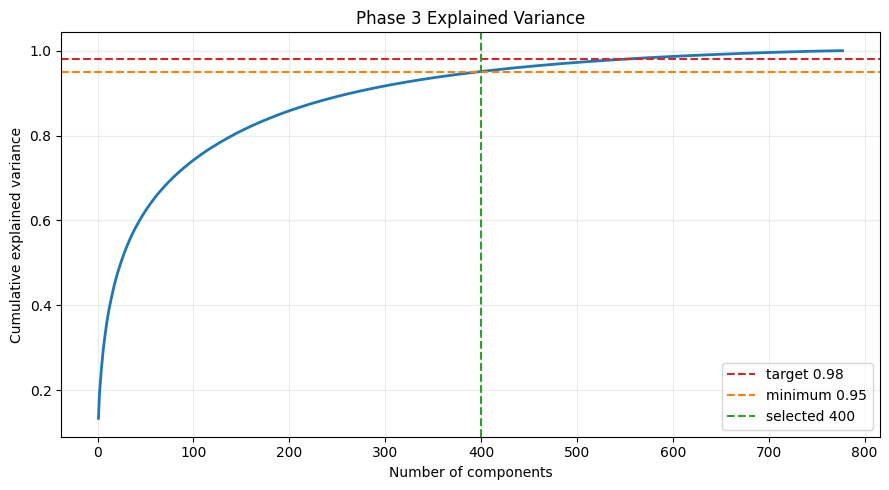

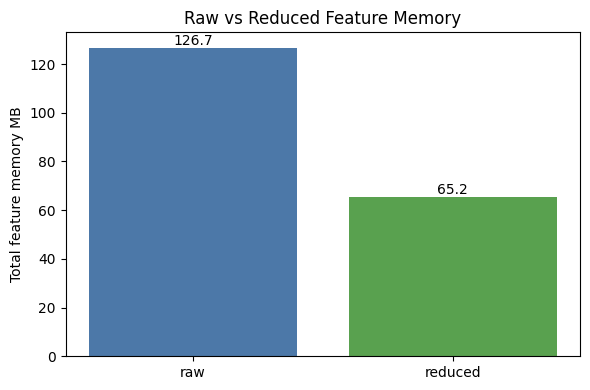

Saved explained variance figure: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase3_explained_variance.png
Saved memory figure: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase3_memory_before_after.png


In [13]:
# explained_variance_figure_path: hình cumulative explained variance
explained_variance_figure_path = REPORT_FIGURE_DIR / 'phase3_explained_variance.png'
# memory_figure_path: hình so sánh RAM trước/sau PCA
memory_figure_path = REPORT_FIGURE_DIR / 'phase3_memory_before_after.png'

# plt.figure: vẽ đường cumulative variance và các ngưỡng target/min/selected
plt.figure(figsize=(9, 5))
# plt.plot(: vẽ đồ thị đường
plt.plot(
    # component_variance['component'],: thực thi lệnh Python
    component_variance['component'],
    # component_variance['cumulative_explained_variance'],: thực thi lệnh Python
    component_variance['cumulative_explained_variance'],
    # linewidth = ...: gán giá trị cho biến linewidth
    linewidth=2,
# ): đóng ngoặc gọi hàm
)
# plt.axhline(VARIANCE_TARGET, color='tab:red', linestyle='--', label=f'target {VA...: vẽ đường ngang tham chiếu
plt.axhline(VARIANCE_TARGET, color='tab:red', linestyle='--', label=f'target {VARIANCE_TARGET:.2f}')
# plt.axhline(VARIANCE_MINIMUM, color='tab:orange', linestyle='--', label=f'minimu...: vẽ đường ngang tham chiếu
plt.axhline(VARIANCE_MINIMUM, color='tab:orange', linestyle='--', label=f'minimum {VARIANCE_MINIMUM:.2f}')
# plt.axvline(selected_components, color='tab:green', linestyle='--', label=f'sele...: vẽ đường dọc tham chiếu
plt.axvline(selected_components, color='tab:green', linestyle='--', label=f'selected {selected_components}')
# plt.xlabel('Number of components'): đặt nhãn trục X
plt.xlabel('Number of components')
# plt.ylabel('Cumulative explained variance'): đặt nhãn trục Y
plt.ylabel('Cumulative explained variance')
# plt.title('Phase 3 Explained Variance'): đặt tiêu đề biểu đồ
plt.title('Phase 3 Explained Variance')
# plt.grid(alpha=0.25): thực thi lệnh Python
plt.grid(alpha=0.25)
# plt.legend(): hiển thị chú thích
plt.legend()
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# plt.savefig(explained_variance_figure_path, dpi=160): lưu biểu đồ ra file hình
plt.savefig(explained_variance_figure_path, dpi=160)
# plt.show(): hiển thị biểu đồ
plt.show()

# memory_plot = ...: gán giá trị cho biến memory plot
memory_plot = (
    # memory_report.groupby('stage', as_index=False)['memory_mb']: nhóm dữ liệu theo cột
    memory_report.groupby('stage', as_index=False)['memory_mb']
    # .sum(): tính tổng
    .sum()
    # .sort_values('stage'): thực thi lệnh Python
    .sort_values('stage')
# ): đóng ngoặc gọi hàm
)
# plt.figure(figsize=(6, 4)): tạo figure matplotlib mới
plt.figure(figsize=(6, 4))
# plt.bar(memory_plot['stage'], memory_plot['memory_mb'], color=[': vẽ biểu đồ cột
plt.bar(memory_plot['stage'], memory_plot['memory_mb'], color=['#4C78A8', '#59A14F'])
# plt.ylabel('Total feature memory MB'): đặt nhãn trục Y
plt.ylabel('Total feature memory MB')
# plt.title('Raw vs Reduced Feature Memory'): đặt tiêu đề biểu đồ
plt.title('Raw vs Reduced Feature Memory')
# for: vòng lặp — for idx, row in memory_plot.iterrows():
for idx, row in memory_plot.iterrows():
    # plt.text(idx, row['memory_mb'], f"{row['memory_mb']:.1f}", ha='center', va='bott...: thực thi lệnh Python
    plt.text(idx, row['memory_mb'], f"{row['memory_mb']:.1f}", ha='center', va='bottom')
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# plt.savefig(memory_figure_path, dpi=160): lưu biểu đồ ra file hình
plt.savefig(memory_figure_path, dpi=160)
# plt.show(): hiển thị biểu đồ
plt.show()

# print('Saved explained variance figure:', explained_variance_figure_path): in thông tin ra console
print('Saved explained variance figure:', explained_variance_figure_path)
# print('Saved memory figure:', memory_figure_path): in thông tin ra console
print('Saved memory figure:', memory_figure_path)


## Phase 3 Completion Checklist

- PCA-01: Reducer/scaler fit on train only; validation/test transformed only.
- PCA-02: Component count selected from explained variance target and preferred 300-400 range.
- PCA-03: Reducer object, reduced train/validation/test features, and explained variance figure saved.
- PCA-04: Memory before/after table and figure saved.

Phase 4 and Phase 5 should load:

- `artifacts/pca/features_final_train.npy`
- `artifacts/pca/features_final_val.npy`
- `artifacts/pca/features_final_test.npy`
- `artifacts/pca/labels_train.npy`
- `artifacts/pca/labels_val.npy`
- `artifacts/pca/labels_test.npy`
- `artifacts/pca/phase3_metadata.json`